# 課題と解答例：2人の線形ODE

元Notebook：[41_love_dynamics_two_person.ipynb](../41_love_dynamics_two_person.ipynb)

課題，解答と必要な関数だけをまとめた独立実行用Notebookである．上から順に実行する．

## 課題

実装後は関数の返り値と `assert` を使い，既知の解で検証する．数値の許容幅による判定と数学的な境界の判定は区別する．

1. `classify_linear_system(M)` を作り，トレース，行列式，固有値，最大実部，分類を辞書で返す．安定節点，鞍点，安定焦点を確認する．実部が0付近なら境界付近と返し，中心とゼロ固有値の例を手計算で区別する．
2. `simulate_linear_system(M, x0, t_end, rtol, atol)` を作り，時刻と2成分をDataFrameで返す．積分の成否，有限値，入力形状を確認し，行列指数関数との最大絶対誤差を求める．
3. 鞍点 $M=\operatorname{diag}(1,-1)$ を，初期値 $(0,1)^\top$ と $(10^{-3},1)^\top$ で比較するコードを書け．同じ不安定な系に収束する軌道があることを図と数値で確かめよ．
4. `accuracy_table(M, x0, times, rtols)` を作り，`atol=rtol/100` として参照解との最大絶対誤差と関数評価回数を表にする．基準の焦点で許容誤差を小さくした場合を比較する．`t_eval` の点数を増やすこととの違いも記す．
5. `transient_gain(M, x0, times)` を作り，保存時刻での最大ノルムを初期ノルムで割った値と，その時刻を返す．$M=\begin{pmatrix}-1&K\\0&-1\end{pmatrix}$，$\mathbf{x}(0)=(0,1)^\top$ で $K=0,2,6$ を比較する．この最大値は連続時間の真の最大値を下から近似するので，保存時刻を細かくした場合も確認する．

## 実行に必要な定義

本編と同じ参照解と数値積分の関数を用いる．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [2]:
def square_matrix(matrix):
    raw = np.asarray(matrix)
    if np.iscomplexobj(raw):
        raise ValueError('This notebook uses real matrices.')
    matrix = np.asarray(raw, dtype=float)
    if (matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]
            or matrix.shape[0] == 0 or not np.all(np.isfinite(matrix))):
        raise ValueError('matrix must be a nonempty finite square matrix')
    return matrix


def linear_inputs(matrix, x0, times):
    matrix = square_matrix(matrix)
    if np.iscomplexobj(x0) or np.iscomplexobj(times):
        raise ValueError('states and times must be real')
    x0, times = np.asarray(x0, dtype=float), np.asarray(times, dtype=float)
    if x0.shape != (matrix.shape[0],) or not np.all(np.isfinite(x0)):
        raise ValueError('x0 must match the matrix dimension and be finite')
    if (times.ndim != 1 or len(times) < 2 or not np.all(np.isfinite(times))
            or np.any(np.diff(times) <= 0)):
        raise ValueError('times must contain at least two increasing finite values')
    return matrix, x0, times


def solve_linear(matrix, x0, times, rtol=1e-8, atol=1e-10):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    if not (np.isfinite(rtol) and np.isfinite(atol) and rtol > 0 and atol > 0):
        raise ValueError('rtol and atol must be finite and positive')
    sol = solve_ivp(lambda t, x: matrix @ x, (times[0], times[-1]), x0,
                    t_eval=times, rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(sol.message)
    if sol.y.shape != (len(x0), len(times)) or not np.all(np.isfinite(sol.y)):
        raise RuntimeError('incomplete or nonfinite solution')
    return sol


def linear_reference(matrix, x0, times):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    result = np.column_stack([expm(matrix * (t - times[0])) @ x0 for t in times])
    if not np.all(np.isfinite(result)):
        raise RuntimeError('nonfinite matrix-exponential reference')
    return result

## 分類関数の解答例

実部が0に近ければ判断を保留する．中心は安定，ゼロ固有値のせん断は不安定なので，境界付近という返り値の後に数式で区別する必要がある．

In [3]:
def classify_linear_system(M, tol=1e-10):
    M = square_matrix(M)
    if M.shape != (2, 2):
        raise ValueError('classification here is for real 2 by 2 matrices')
    if not np.isfinite(tol) or tol <= 0:
        raise ValueError('tol must be finite and positive')
    eig = np.linalg.eigvals(M)
    eps = tol * max(1.0, np.linalg.norm(M, ord=2))
    real = eig.real
    if real.max() < -eps:
        label = 'stable focus' if np.any(np.abs(eig.imag) > eps) else 'stable node'
        stability = 'asymptotically stable'
    elif real.min() < -eps and real.max() > eps:
        label, stability = 'saddle', 'unstable'
    elif real.max() > eps:
        label, stability = 'unstable', 'unstable'
    else:
        # Pure imaginary, zero, and tiny real parts require analytic examination.
        label, stability = 'near boundary: inspect analytically', 'undetermined'
    return {'trace': float(np.trace(M)), 'det': float(np.linalg.det(M)),
            'eigenvalues': eig, 'max_real': float(real.max()),
            'eigenvalue_tolerance': eps, 'classification': label, 'stability': stability}

In [4]:
cases = {'stable node': np.diag([-1., -2.]), 'saddle': np.diag([1., -1.]),
         'stable focus': np.array([[-.2, 1.], [-1., -.2]]),
         'center': np.array([[0., 1.], [-1., 0.]]),
         'shear': np.array([[0., 1.], [0., 0.]])}
for name, matrix in cases.items():
    result = classify_linear_system(matrix)
    print(name, result['eigenvalues'], result['classification'])
assert classify_linear_system(cases['center'])['stability'] == 'undetermined'
assert classify_linear_system(cases['shear'])['stability'] == 'undetermined'

stable node [-1. -2.] stable node
saddle [ 1. -1.] saddle
stable focus [-0.2+1.j -0.2-1.j] stable focus
center [0.+1.j 0.-1.j] near boundary: inspect analytically
shear [0. 0.] near boundary: inspect analytically


## 時系列と誤差・増幅指標の関数

課題2，4，5の関数を定義する．最大ノルム比は指定初期値と保存時刻列に対する値で，すべての初期値・全時刻にわたる最大増幅ではない．

In [5]:
def simulate_linear_system(M, x0, t_end=30, rtol=1e-8, atol=1e-10):
    if square_matrix(M).shape != (2, 2):
        raise ValueError('this wrapper returns two state columns')
    if not np.isfinite(t_end) or t_end <= 0:
        raise ValueError('t_end must be finite and positive')
    times = np.linspace(0, t_end, 600)
    sol = solve_linear(M, x0, times, rtol=rtol, atol=atol)
    return pd.DataFrame({'t': sol.t, 'x1': sol.y[0], 'x2': sol.y[1]})


def accuracy_table(M, x0, times, rtols):
    reference = linear_reference(M, x0, times)
    rows = []
    for rtol in rtols:
        sol = solve_linear(M, x0, times, rtol=rtol, atol=rtol/100)
        rows.append({'rtol': rtol, 'atol': rtol/100, 'nfev': sol.nfev,
                     'max_abs_error': float(np.max(np.abs(sol.y-reference)))})
    return pd.DataFrame(rows, columns=['rtol', 'atol', 'nfev', 'max_abs_error'])


def transient_gain(M, x0, times):
    M, x0, times = linear_inputs(M, x0, times)
    norm0 = np.linalg.norm(x0)
    if norm0 == 0:
        raise ValueError('gain requires a nonzero initial state')
    sol = solve_linear(M, x0, times)
    norms = np.linalg.norm(sol.y, axis=0)
    index = int(np.argmax(norms))
    return {'sampled_peak_gain': float(norms[index]/norm0),
            'sampled_peak_time': float(times[index])}

In [6]:
M = cases['stable focus']
x0 = np.array([1., .2])
table = simulate_linear_system(M, x0, 30)
reference = linear_reference(M, x0, table.t.to_numpy())
error = np.max(np.abs(table[['x1', 'x2']].to_numpy().T-reference))
print(table.head().to_string(index=False))
print('max absolute error:', error)
assert error < 1e-7

       t       x1        x2
0.000000 1.000000  0.200000
0.050083 0.998705  0.148195
0.100167 0.994856  0.097034
0.150250 0.988515  0.046638
0.200334 0.979747 -0.002879
max absolute error: 3.0816534324351608e-09


## 鞍点の初期値比較

$x_1(0)=0$ なら $x_1(t)=0$ のままなので収束する．$x_1(0)=10^{-3}$ なら $x_1(t)=10^{-3}e^t$ が増大する．同じ行列で，系はどちらも不安定である．

initial: [0. 1.] final: {'t': 10.0, 'x1': 0.0, 'x2': 4.539995580240101e-05}
initial: [0.001 1.   ] final: {'t': 10.0, 'x1': 22.026466355021014, 'x2': 4.5399931401079984e-05}


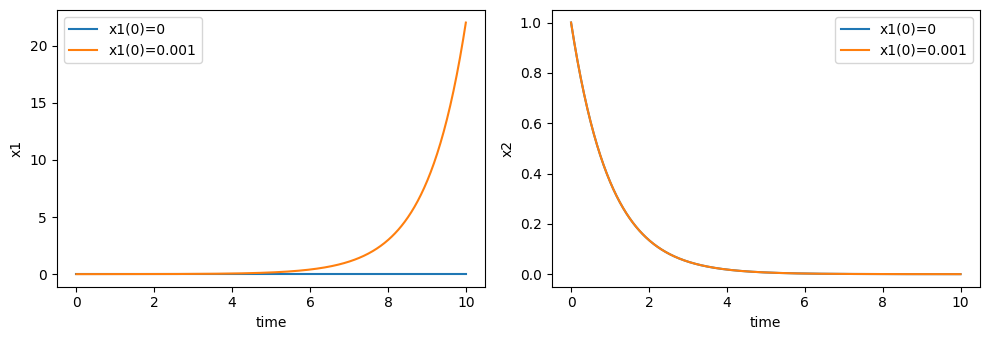

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for initial in [np.array([0., 1.]), np.array([1e-3, 1.])]:
    frame = simulate_linear_system(cases['saddle'], initial, t_end=10)
    exact = np.array([initial[0]*np.exp(frame.t), initial[1]*np.exp(-frame.t)])
    np.testing.assert_allclose(frame[['x1','x2']].to_numpy().T, exact, rtol=1e-7, atol=1e-8)
    for i, column in enumerate(['x1', 'x2']):
        axes[i].plot(frame.t, frame[column], label=f'x1(0)={initial[0]:g}')
    print('initial:', initial, 'final:', frame.iloc[-1].to_dict())
for i, ax in enumerate(axes):
    ax.set(xlabel='time', ylabel=f'x{i+1}'); ax.legend()
fig.tight_layout(); plt.show()

## 許容誤差の比較

同じ出力点で許容誤差を変える．この例では厳しくすると参照解との差が小さくなる．すべての問題で誤差が単調に減ることを保証するものではない．

In [8]:
times = np.linspace(0, 30, 601)
errors = accuracy_table(M, x0, times, [1e-3, 1e-6, 1e-9])
print(errors.to_string(index=False))
assert errors.iloc[-1].max_abs_error < errors.iloc[0].max_abs_error/100

        rtol         atol  nfev  max_abs_error
1.000000e-03 1.000000e-05   218   4.656014e-04
1.000000e-06 1.000000e-08   764   3.405315e-07
1.000000e-09 1.000000e-11  2984   3.025994e-10


## 一時的増幅と保存時刻の比較

厳密解 $e^{-t}(Kt,1)^\top$ にも同じ増幅が現れるため，数値誤差による発散ではない．各行の初期ノルムは1である．ピークを求める時間窓は0から10に固定する．

In [9]:
rows = []
for K in [0., 2., 6.]:
    matrix = np.array([[-1., K], [0., -1.]])
    for count in [51, 1001]:
        row = transient_gain(matrix, [0., 1.], np.linspace(0, 10, count))
        row.update(K=K, saved_points=count)
        rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))
assert rows[0]['sampled_peak_gain'] == 1.0
assert rows[-1]['sampled_peak_gain'] > 2.0

 sampled_peak_gain  sampled_peak_time   K  saved_points
          1.000000               0.00 0.0            51
          1.000000               0.00 0.0          1001
          1.000000               0.00 2.0            51
          1.000000               0.00 2.0          1001
          2.237723               1.00 6.0            51
          2.238594               0.97 6.0          1001
